# Debug Tracer — per-iteration visualization

`DebugTracer` is a toggleable debugging component for `iterative_serial`.
It records convergence history and optionally shows a 3-panel snapshot
(before Jdet / after Jdet / |Δφ|) after every N outer iterations.

Pass `debug=True` for default settings, or `debug=DebugTracer(show_every=2)` to customize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dvfopt import iterative_serial, jacobian_det2D
from test_cases import make_deformation
from dvfopt.viz import DebugTracer, plot_grid_before_after

## 1. Build a test deformation field

Use a synthetic case that has negative Jacobian determinants.

In [2]:
case_key = "01a_10x10_crossing"
dvf, _, _ = make_deformation(case_key)

jac_init = jacobian_det2D(dvf[1:, ...])
print(f"Shape: {dvf.shape}")
print(f"Neg Jdet pixels: {int((jac_init <= 0).sum())}")
print(f"Min Jdet: {float(jac_init.min()):.4f}")

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Shape: (3, 1, 10, 10)
Neg Jdet pixels: 9
Min Jdet: -1.0292


## 2. Run with debug tracing — show every iteration

Each outer iteration shows:
- **Left**: Jdet before the fix, with the optimisation window outlined
- **Middle**: Jdet after the fix, with negative-region contour
- **Right**: Displacement change magnitude |Δφ| — reveals exactly which region was modified

[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.029169


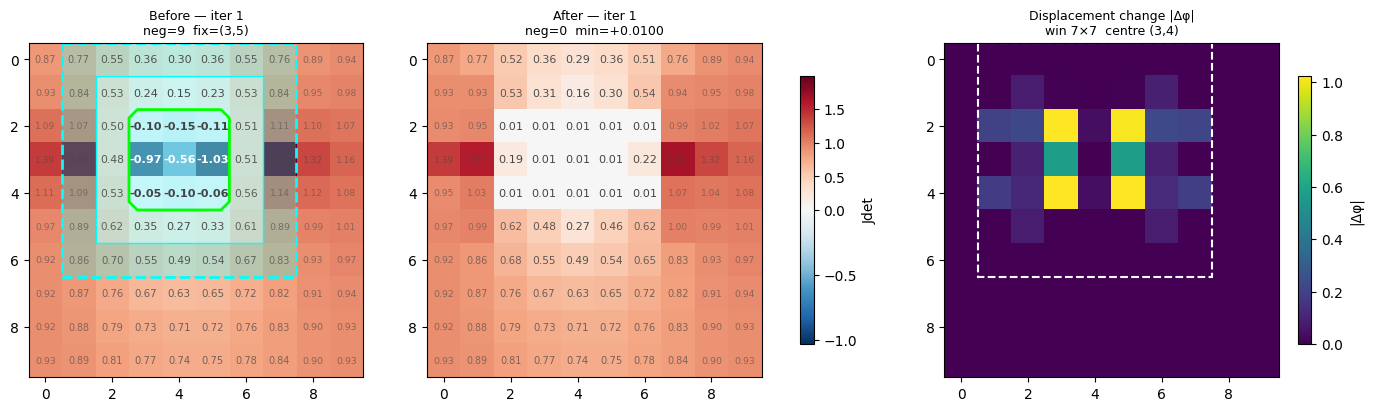

[iter    1]  fix (  3,  5)  win 7x7  neg_jdet     0  min_jdet +0.010000  L2 2.2709  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1
  Neg-Jdet      9 ->     0
  Min Jdet  -1.029169 -> +0.010000
  L2 error         : 2.270910
  Time             : 0.71s


In [3]:
tracer = DebugTracer(show_every=1, show_sub_iters=False)

phi = iterative_serial(
    dvf,
    verbose=1,
    debug=tracer,
)

## 3. Convergence history

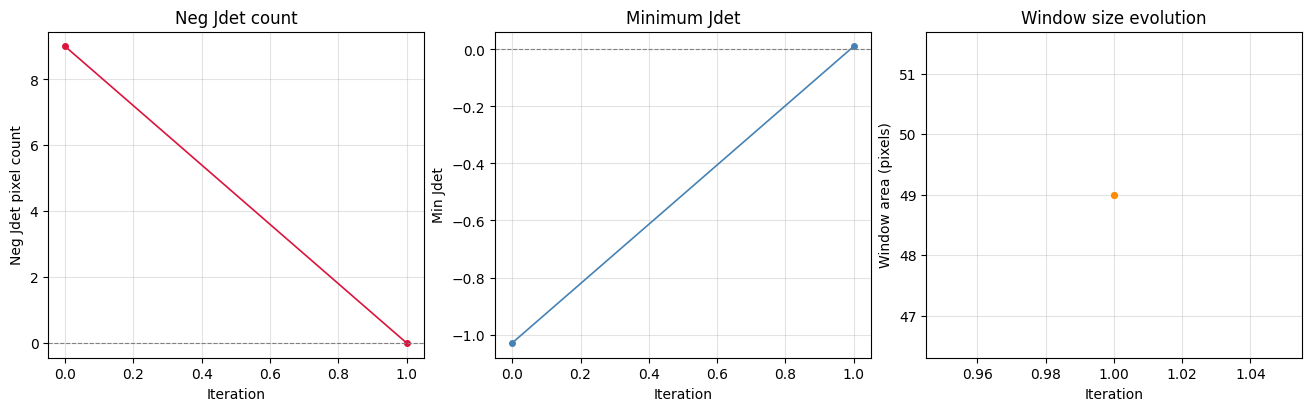

In [4]:
tracer.plot_history()

## 4. Before / after deformation grid

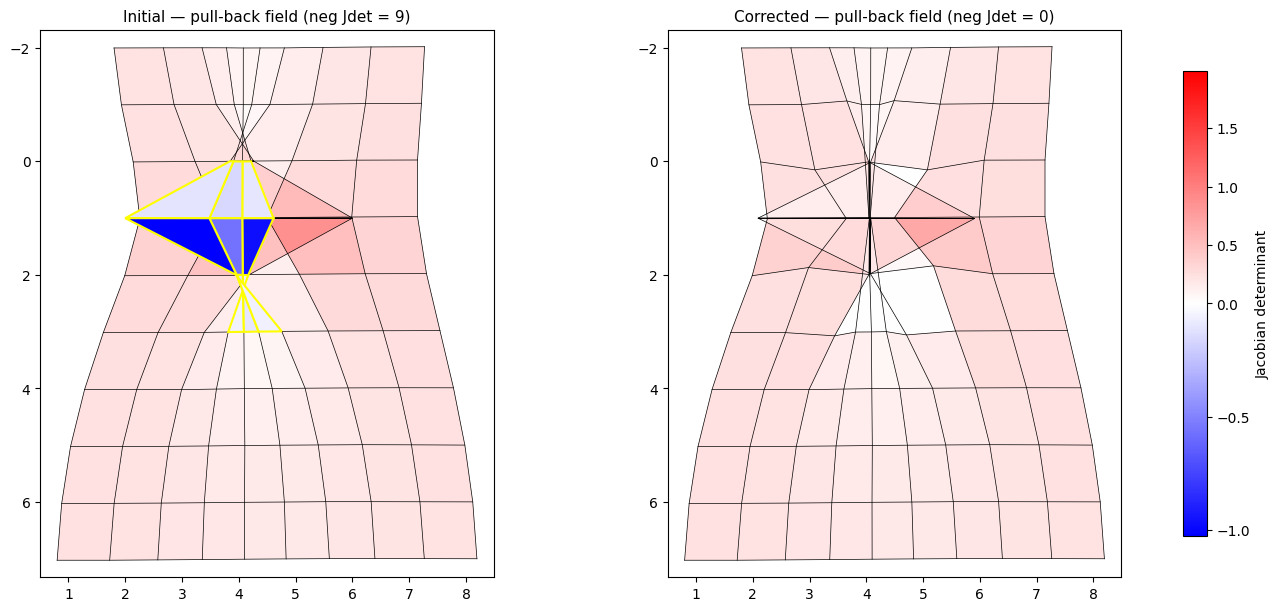

In [5]:
phi_4d = np.stack([np.zeros_like(phi[0]), phi[0], phi[1]])[: , np.newaxis]
plot_grid_before_after(dvf, phi)

## 5. Try a harder case — show every 2 iterations, with sub-iteration tracing

In [6]:
case_key2 = "01d_20x40_crossing"
dvf2, _, _ = make_deformation(case_key2)

jac2 = jacobian_det2D(dvf2[1:, ...])
print(f"Shape: {dvf2.shape}")
print(f"Neg Jdet pixels: {int((jac2 <= 0).sum())}")
print(f"Min Jdet: {float(jac2.min()):.4f}")

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Shape: (3, 1, 20, 40)
Neg Jdet pixels: 159
Min Jdet: -3.1742


[init] Grid 20x40  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 159  |  min Jdet: -3.174200


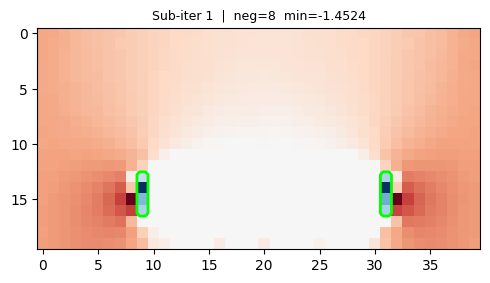

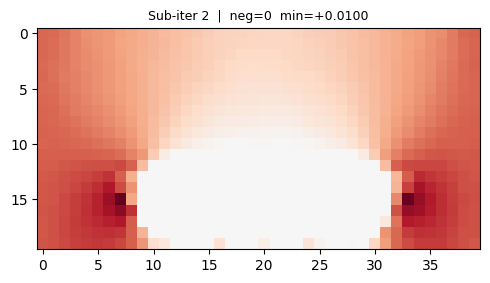

[iter    1]  fix ( 15, 11)  win 14x25  neg_jdet     0  min_jdet +0.010000  L2 16.4853  sub-iters 2
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 20 x 40
  Iterations       : 1
  Neg-Jdet    159 ->     0
  Min Jdet  -3.174200 -> +0.010000
  L2 error         : 16.485328
  Time             : 10.46s


In [7]:
tracer2 = DebugTracer(
    show_every=2,        # snapshot every 2 outer iterations
    show_sub_iters=True, # also show sub-iteration Jdet heatmaps
)

phi2 = iterative_serial(
    dvf2,
    verbose=1,
    debug=tracer2,
)

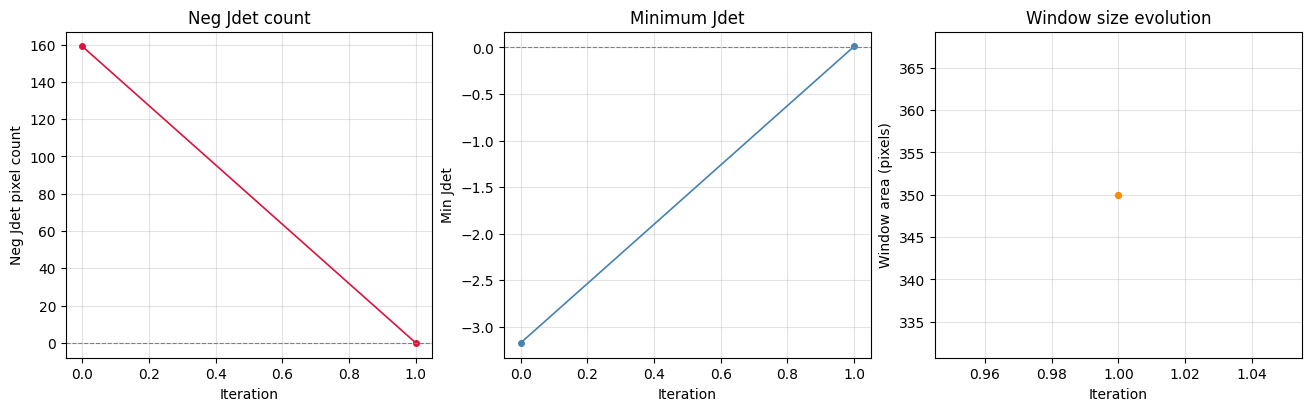

In [8]:
tracer2.plot_history()

## 6. Silent tracing — no snapshots during run, only history afterwards

Set `show_every=0` to suppress inline plots while still collecting history.

In [9]:
tracer3 = DebugTracer(show_every=0)  # silent

phi3 = iterative_serial(dvf, verbose=0, debug=tracer3)

# Inspect raw history arrays
print("Iterations:", tracer3.iterations)
print("Neg counts: ", tracer3.neg_counts)
print("Min Jdets:  ", [f"{v:.4f}" for v in tracer3.min_jdets])
print("Windows:    ", tracer3.window_sizes)
print("Sub-iters:  ", tracer3.sub_iter_counts)

Iterations: [0, 1]
Neg counts:  [9, 0]
Min Jdets:   ['-1.0292', '0.0100']
Windows:     [(7, 7)]
Sub-iters:   [1]


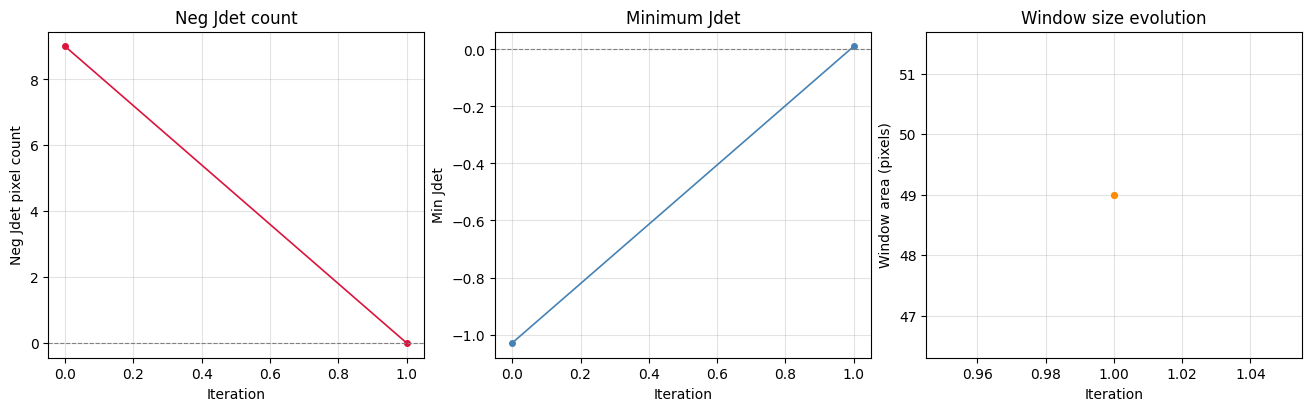

In [10]:
tracer3.plot_history()